n = 513
N low signal = 78 (15.2%)
Accuracy = 0.67
ROC AUC = 0.76
Model Coefficient = -0.31
Model Intercept = 1.98


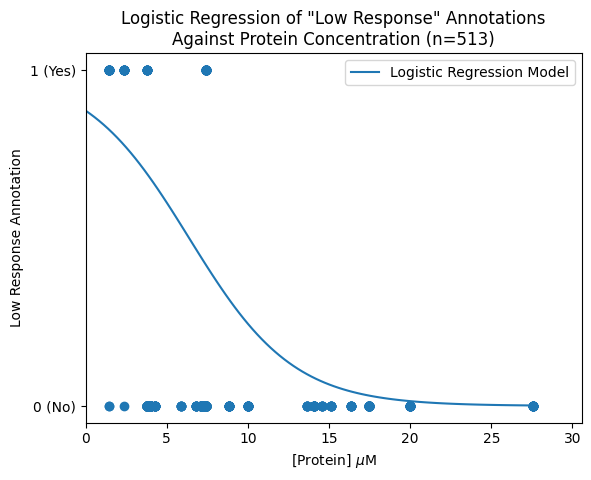

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.special import expit

sql = '''select 
r.id,
c.name,
r.protein_concentration,
-- w.protein_concentration,
w.volume,
-- dispense_assay_mix,
-- dispense_ligands,
-- centrifuge_minutes,
-- centrifuge_rpm,
-- protein_days_thawed,
r.km,
r.vmax,
r.r_squared,
group_concat(distinct ra.comment) as comments,
r.locked,
r.accepted

from result r
join wellresultlink wr
on r.id = wr.result_id
join well w
on wr.well_id = w.id
left join resultannotation ra
on r.id = ra.result_id
join compound c
on c.id = r.compound_id
join experiment e
on e.id = r.experiment_id
where 
locked = 1
group by r.id
order by r.id
'''
with sqlite3.connect('../api/database.db') as con:
    df = pd.read_sql(sql, con)

df['Low Signal'] = df['comments'].str.contains('Low Signal').astype(bool)

xy = df[['protein_concentration', 'Low Signal']].dropna()
x = xy['protein_concentration'].values.reshape(-1, 1)
y = xy['Low Signal'].values
model = LogisticRegression(class_weight='balanced')
model.fit(x, y)
accuracy = model.score(x, y)

# y_pred_prob = model.predict_log_proba(x)
y_pred_prob = model.predict_proba(x) # columns: probs no, props low response
roc_score = roc_auc_score(y, y_pred_prob[:, 1])

print(f'n = {len(x)}')
print(f'N low signal = {sum(y)} ({sum(y)/len(x):.1%})')
print(f'Accuracy = {accuracy:.2f}')
print(f'ROC AUC = {roc_score:.2f}')
print(f'Model Coefficient = {model.coef_[0][0]:.2f}')
print(f'Model Intercept = {model.intercept_[0]:.2f}')


odir = 'volume'
if not os.path.exists(odir):
    os.mkdir(odir)

x_ = np.linspace(0, max(x), 100)
y_pred = expit(x_ * model.coef_ + model.intercept_).ravel()

plt.plot(x_, y_pred, label='Logistic Regression Model')
plt.scatter(x, y)
plt.xlim(0, max(x) + 3)
plt.xlabel('[Protein] $\mu$M')
plt.ylabel('Low Response Annotation')
plt.yticks([0,1], ['0 (No)','1 (Yes)'])
plt.title(f'Logistic Regression of "Low Response" Annotations\nAgainst Protein Concentration (n={len(x)})')
plt.legend()
plt.savefig(os.path.join(odir, 'logistic-regression-volume.png'))
plt.show()

In [2]:
concs = np.linspace(0, 20, 9).reshape(-1, 1)

preds = model.predict_proba(concs)
probs_low_signal = preds[:, 1]

print(pd.DataFrame([concs.reshape(-1), probs_low_signal], 
                   index=[
                       'Protein Concentration', 
                       'Probability of Low Signal'
                   ]).T.to_markdown(
    index=False,
    floatfmt="0.2f"
))

|   Protein Concentration |   Probability of Low Signal |
|------------------------:|----------------------------:|
|                    0.00 |                        0.88 |
|                    2.50 |                        0.77 |
|                    5.00 |                        0.61 |
|                    7.50 |                        0.41 |
|                   10.00 |                        0.24 |
|                   12.50 |                        0.13 |
|                   15.00 |                        0.06 |
|                   17.50 |                        0.03 |
|                   20.00 |                        0.01 |


In [17]:
xy = df[['volume', 'protein_concentration', 'Low Signal']].dropna()
x = xy[['volume', 'protein_concentration']].values
y = xy['Low Signal'].values

model = LogisticRegression(class_weight='balanced')
model.fit(x, y)
accuracy = model.score(x, y)

# y_pred_prob = model.predict_log_proba(x)
y_pred_prob = model.predict_proba(x) # columns: probs no, props low response
roc_score = roc_auc_score(y, y_pred_prob[:, 1])

print(f'n = {len(x)}')
print(f'N low signal = {sum(y)} ({sum(y)/len(x):.1%})')
print(f'Accuracy = {accuracy:.2f}')
print(f'ROC AUC = {roc_score:.2f}')
print(f'Model Coefficients = {model.coef_[0][0]:.2f}, {model.coef_[0][1]:.2f}')
print(f'Model Intercept = {model.intercept_[0]:.2f}')

n = 513
N low signal = 78 (15.2%)
Accuracy = 0.90
ROC AUC = 0.94
Model Coefficients = -0.24, -1.15
Model Intercept = 16.31


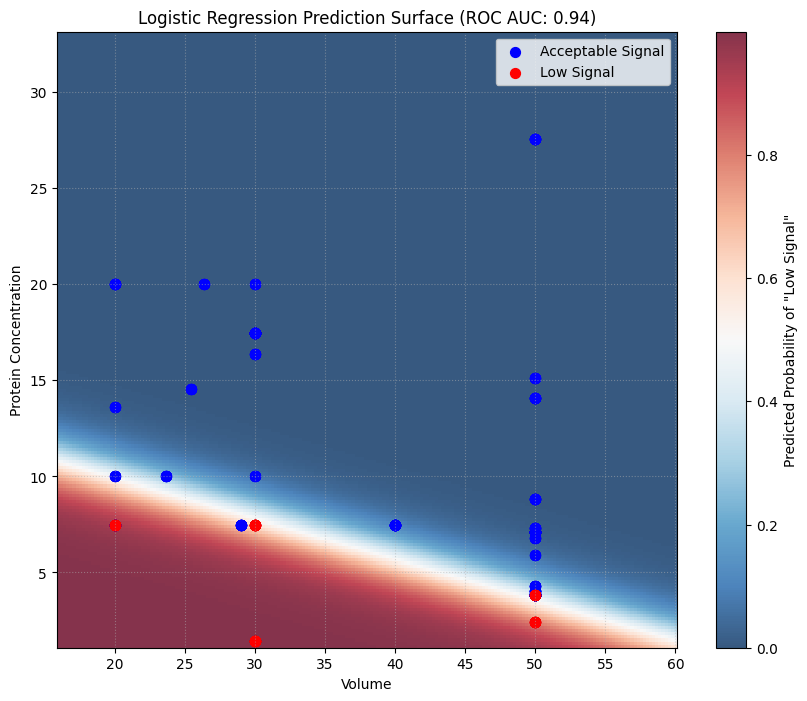

In [36]:
xx, yy = np.meshgrid(np.linspace(min(xy['volume'])*0.8, max(xy['volume'])*1.2, 200),
                     np.linspace(min(xy['protein_concentration'])*0.8, max(xy['protein_concentration'])*1.2, 200))

Z_input = np.c_[xx.ravel(), yy.ravel()]
Z_prob = model.predict_proba(Z_input)[:, 1]
Z_prob = Z_prob.reshape(xx.shape)

plt.figure(figsize=(10, 8))
heatmap = plt.pcolormesh(xx, yy, Z_prob, cmap=plt.cm.RdBu_r, shading='auto', alpha=0.8)
cbar = plt.colorbar(heatmap)
cbar.set_label('Predicted Probability of "Low Signal"')
xy_pos = xy.loc[xy['Low Signal'] == True, :]
xy_neg = xy.loc[xy['Low Signal'] != True, :]
plt.scatter(xy_neg['volume'], 
            xy_neg['protein_concentration'], 
            c='b', 
            s=50, 
            label='Acceptable Signal')

plt.scatter(xy_pos['volume'], 
            xy_pos['protein_concentration'], 
            c='r', 
            s=50, 
            label='Low Signal')

# --- 5. Finalize the Plot ---

plt.xlabel('Volume')
plt.ylabel('Protein Concentration')
plt.title(f'Logistic Regression Prediction Surface (ROC AUC: {roc_score:.2f})')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.savefig(os.path.join(odir, 'logistic-regression-volume-concentration.png'))
plt.show()